# QUANTITATIVE ANALYSIS OF GOLD PRICES: INSIGHTS THROUGH MACHINE LEARNING MODELS
### Dataset: gold_new.csv (1925–2025) | Binary Classification + SHAP Explainability

##  1. Install Packages

In [4]:
!pip install gradio joblib seaborn scikit-learn shap

## 2. Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import gradio as gr

print('Libraries Imported')

Libraries Imported


## 3. Load Dataset

In [6]:
data = pd.read_csv('gold_new.csv')

print('Dataset Shape:', data.shape)
print('\nFirst 5 Rows:')
print(data.head())
print('\nLast 5 Rows:')
print(data.tail())

Dataset Shape: (101, 4)

First 5 Rows:
   Year  USD to INR  Aver GLD per gram  GLD INR per 10g
0  1925        2.76              1.875            18.75
1  1926        2.75              1.843            18.43
2  1927        2.75              1.837            18.37
3  1928        2.74              1.837            18.37
4  1929        2.76              1.843            18.43

Last 5 Rows:
     Year  USD to INR  Aver GLD per gram  GLD INR per 10g
96   2021       73.50             4809.9          48099.0
97   2022       78.65             5501.7          55017.0
98   2023       82.50             6320.3          63203.0
99   2024       85.61             7824.5          78245.0
100  2025       87.16             9645.0          96450.0


## 4. Data Pre-Processing

In [7]:
# Replace 'na' strings and drop null rows
data.replace('na', np.nan, inplace=True)
data.dropna(inplace=True)
data.drop_duplicates(inplace=True)

# Clean numeric columns
data['Aver GLD per gram'] = data['Aver GLD per gram'].astype(str).str.replace(',','').str.replace('$','')
data['Aver GLD per gram'] = pd.to_numeric(data['Aver GLD per gram'], errors='coerce').abs()

# Sort by Year
data = data.sort_values('Year').reset_index(drop=True)

# Create Target: 1 = UP, 0 = DOWN
data['Price_Direction'] = (data['Aver GLD per gram'].shift(-1) > data['Aver GLD per gram']).astype(int)
data = data.dropna().reset_index(drop=True)

print('\nData after Preprocessing:')
print(data.info())
print('\nTarget Distribution (1=UP, 0=DOWN):')
print(data['Price_Direction'].value_counts())


Data after Preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               101 non-null    int64  
 1   USD to INR         101 non-null    float64
 2   Aver GLD per gram  101 non-null    float64
 3   GLD INR per 10g    101 non-null    float64
 4   Price_Direction    101 non-null    int32  
dtypes: float64(3), int32(1), int64(1)
memory usage: 3.7 KB
None

Target Distribution (1=UP, 0=DOWN):
Price_Direction
1    78
0    23
Name: count, dtype: int64


## 5. Data Visualization

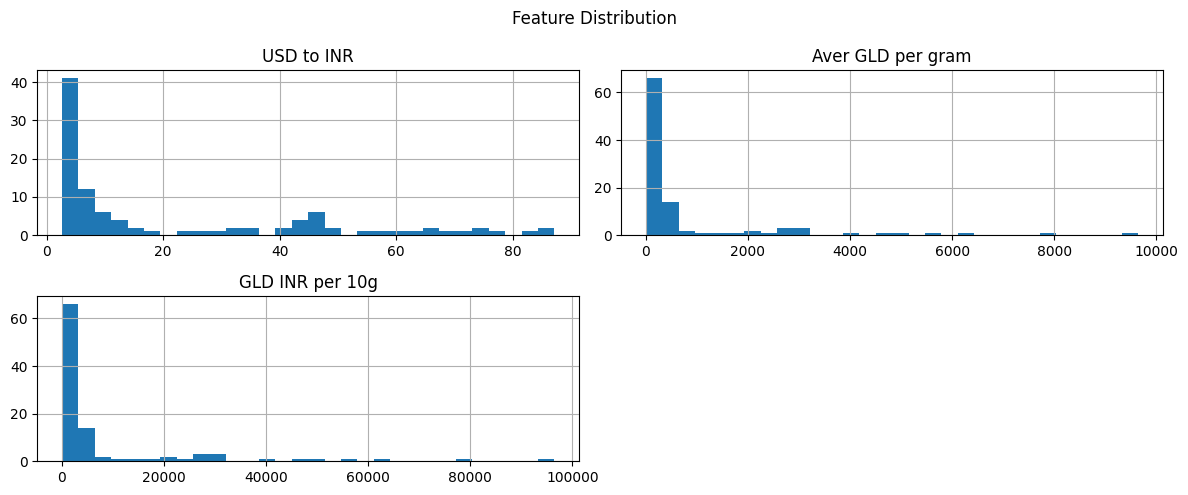

In [8]:
# --- 5.1 Histogram ---
data[['USD to INR', 'Aver GLD per gram', 'GLD INR per 10g']].hist(bins=30, figsize=(12, 5))
plt.suptitle('Feature Distribution')
plt.tight_layout()
plt.show()

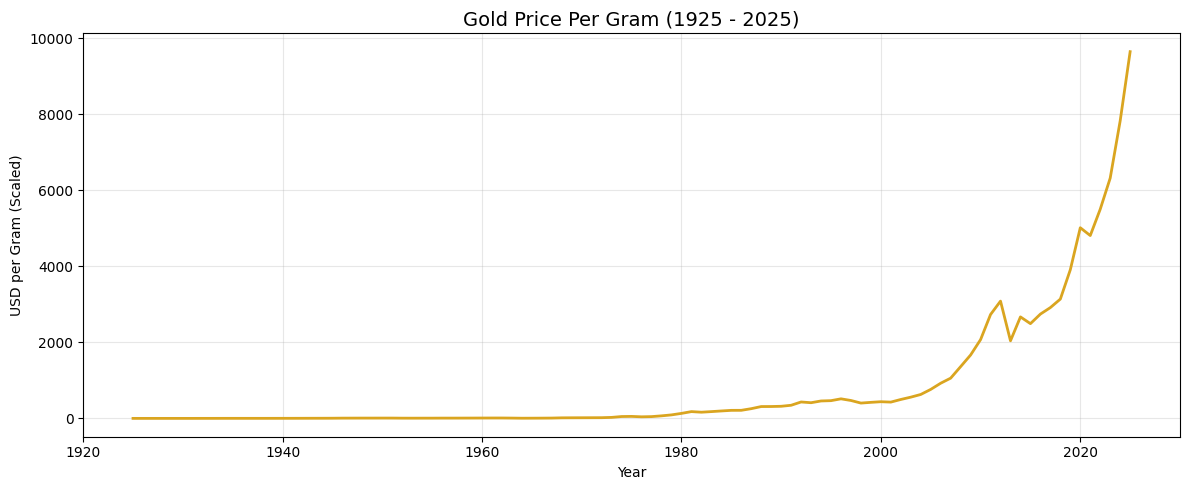

In [9]:
# --- 5.2 Gold Price Over Time ---
plt.figure(figsize=(12, 5))
plt.plot(data['Year'], data['Aver GLD per gram'], color='goldenrod', linewidth=2)
plt.title('Gold Price Per Gram (1925 - 2025)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('USD per Gram (Scaled)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

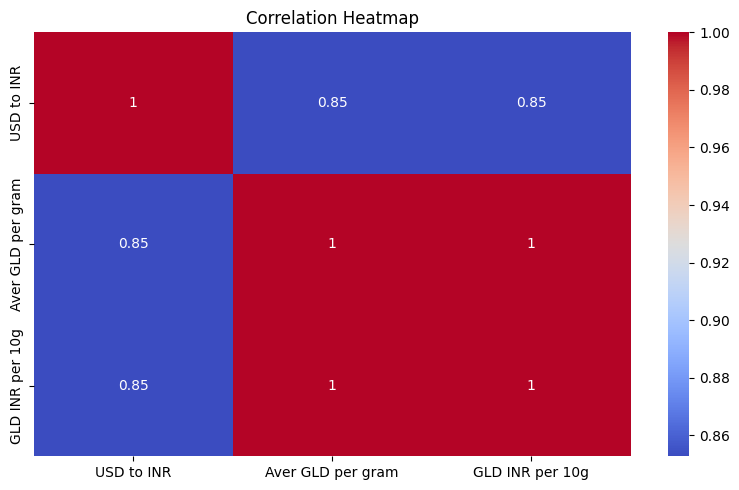

In [10]:
# --- 5.3 Correlation Heatmap ---
plt.figure(figsize=(8, 5))
sns.heatmap(data[['USD to INR', 'Aver GLD per gram', 'GLD INR per 10g']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

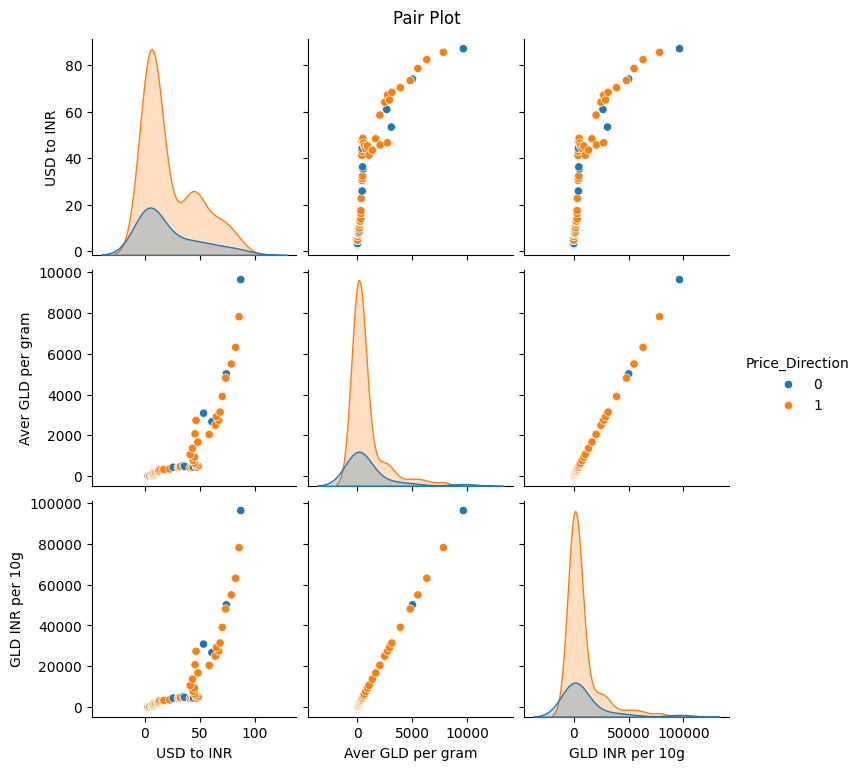

In [11]:
# --- 5.4 Pair Plot ---
sns.pairplot(data[['USD to INR', 'Aver GLD per gram', 'GLD INR per 10g', 'Price_Direction']],
             hue='Price_Direction')
plt.suptitle('Pair Plot', y=1.02)
plt.show()

##  6. Data Scaling

In [12]:
scaler = StandardScaler()
columns_to_scale = ['USD to INR', 'Aver GLD per gram', 'GLD INR per 10g']
data[columns_to_scale] = scaler.fit_transform(data[columns_to_scale])

print('Data after Scaling:')
print(data.head())

Data after Scaling:
   Year  USD to INR  Aver GLD per gram  GLD INR per 10g  Price_Direction
0  1925   -0.790601          -0.475352        -0.475352                0
1  1926   -0.791009          -0.475371        -0.475371                0
2  1927   -0.791009          -0.475374        -0.475374                0
3  1928   -0.791418          -0.475374        -0.475374                1
4  1929   -0.790601          -0.475371        -0.475371                0


## 7. Feature Selection

In [13]:
target   = 'Price_Direction'
X = data[['USD to INR', 'Aver GLD per gram', 'GLD INR per 10g']]
y = data[target]

selector = SelectKBest(mutual_info_classif, k=2)
X_kbest  = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]

print('Selected Features:', list(selected_features))

X_selected = pd.DataFrame(X_kbest, columns=selected_features)
print('\nSelected Feature Data:')
print(X_selected.head())

Selected Features: ['USD to INR', 'Aver GLD per gram']

Selected Feature Data:
   USD to INR  Aver GLD per gram
0   -0.790601          -0.475352
1   -0.791009          -0.475371
2   -0.791009          -0.475374
3   -0.791418          -0.475374
4   -0.790601          -0.475371


## 8. Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

print(f'Train size : {len(X_train)}')
print(f'Test size  : {len(X_test)}')

Train size : 80
Test size  : 21


##  9. Model Training & Comparison

In [15]:
models = {
    'Logistic Regression'  : LogisticRegression(max_iter=1000),
    'Decision Tree'        : DecisionTreeClassifier(random_state=42),
    'Random Forest'        : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'    : GradientBoostingClassifier(random_state=42),
    'SVM'                  : SVC(probability=True),
    'KNN'                  : KNeighborsClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1  = f1_score(y_test, y_pred, zero_division=0)

    results.append([name, acc, pre, rec, f1])

    print(f'{name}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {pre:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1 Score  : {f1:.4f}')
    print()

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])

print('\n MODEL COMPARISON TABLE:')
print(results_df.to_string(index=False))

Logistic Regression
  Accuracy  : 0.7143
  Precision : 0.7143
  Recall    : 1.0000
  F1 Score  : 0.8333

Decision Tree
  Accuracy  : 0.6667
  Precision : 0.7500
  Recall    : 0.8000
  F1 Score  : 0.7742

Random Forest
  Accuracy  : 0.7143
  Precision : 0.7647
  Recall    : 0.8667
  F1 Score  : 0.8125

Gradient Boosting
  Accuracy  : 0.6190
  Precision : 0.7333
  Recall    : 0.7333
  F1 Score  : 0.7333

SVM
  Accuracy  : 0.7143
  Precision : 0.7143
  Recall    : 1.0000
  F1 Score  : 0.8333

KNN
  Accuracy  : 0.7143
  Precision : 0.7368
  Recall    : 0.9333
  F1 Score  : 0.8235


 MODEL COMPARISON TABLE:
              Model  Accuracy  Precision   Recall  F1 Score
Logistic Regression  0.714286   0.714286 1.000000  0.833333
      Decision Tree  0.666667   0.750000 0.800000  0.774194
      Random Forest  0.714286   0.764706 0.866667  0.812500
  Gradient Boosting  0.619048   0.733333 0.733333  0.733333
                SVM  0.714286   0.714286 1.000000  0.833333
                KNN  0.714286 

## 10. Final Model — Random Forest Classifier

In [16]:
# Random Forest selected as Final Model (best for SHAP TreeExplainer)
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print('FINAL MODEL: Random Forest Classifier')
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision : {precision_score(y_test, y_pred, zero_division=0):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred, zero_division=0):.4f}')
print(f'F1 Score  : {f1_score(y_test, y_pred, zero_division=0):.4f}')

cm = confusion_matrix(y_test, y_pred)
print('\nConfusion Matrix:')
print(cm)

FINAL MODEL: Random Forest Classifier
Accuracy  : 0.7143
Precision : 0.7647
Recall    : 0.8667
F1 Score  : 0.8125

Confusion Matrix:
[[ 2  4]
 [ 2 13]]


##  11. Model Performance Plots

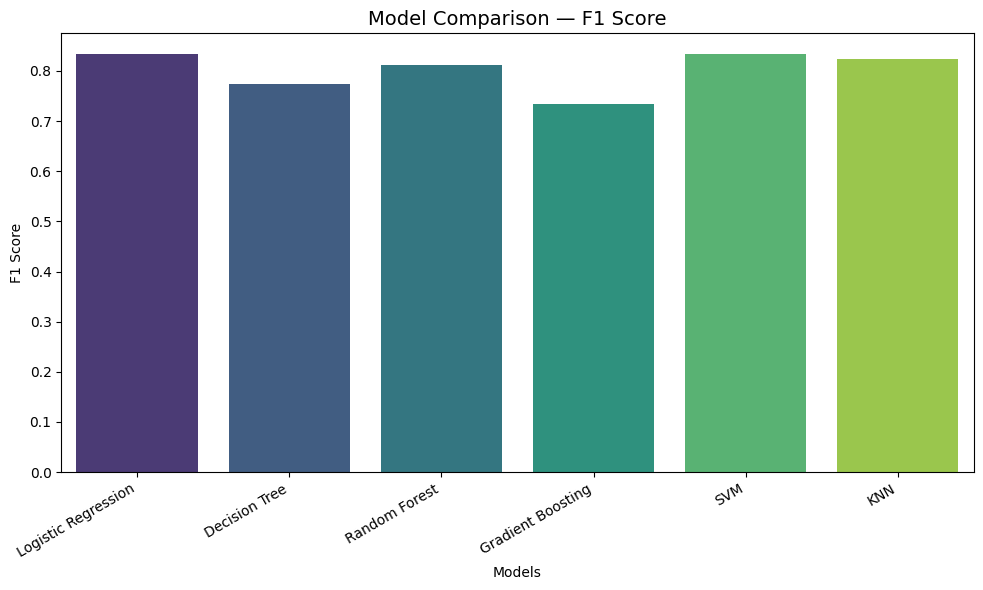

In [17]:
# --- 11.1 Bar Plot — F1 Score Comparison ---
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Model', y='F1 Score',
            hue='Model', palette='viridis', legend=False)
plt.title('Model Comparison — F1 Score', fontsize=14)
plt.xlabel('Models')
plt.ylabel('F1 Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

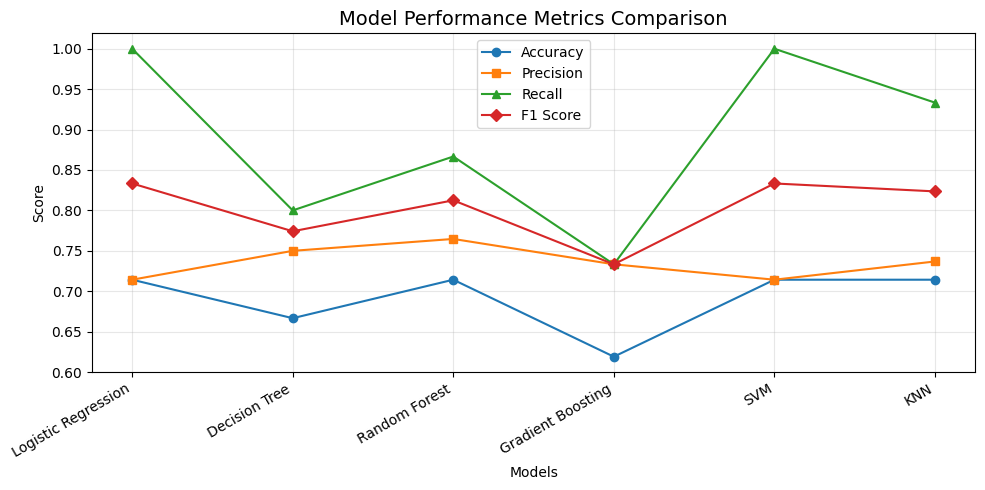

In [18]:
# --- 11.2 Line Plot — All Metrics ---
plt.figure(figsize=(10, 5))
plt.plot(results_df['Model'], results_df['Accuracy'],  marker='o', label='Accuracy')
plt.plot(results_df['Model'], results_df['Precision'], marker='s', label='Precision')
plt.plot(results_df['Model'], results_df['Recall'],    marker='^', label='Recall')
plt.plot(results_df['Model'], results_df['F1 Score'],  marker='D', label='F1 Score')
plt.title('Model Performance Metrics Comparison', fontsize=14)
plt.xlabel('Models')
plt.ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

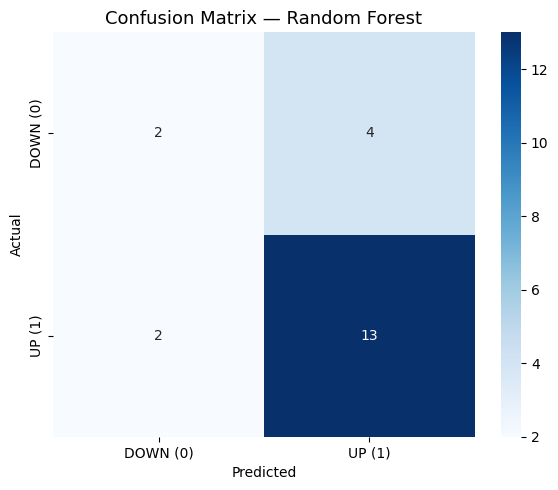

In [19]:
# --- 11.3 Confusion Matrix Heatmap ---
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['DOWN (0)', 'UP (1)'],
            yticklabels=['DOWN (0)', 'UP (1)'])
plt.title('Confusion Matrix — Random Forest', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [20]:
# --- 11.4 Actual vs Predicted ---
result_check = pd.DataFrame({
    'Actual'    : y_test.values,
    'Predicted' : y_pred
})
print('Actual vs Predicted (Test Set):')
print(result_check.to_string(index=False))

Actual vs Predicted (Test Set):
 Actual  Predicted
      1          1
      1          1
      1          1
      0          1
      1          1
      1          1
      1          1
      1          1
      0          1
      0          0
      1          1
      1          1
      1          1
      1          0
      1          0
      0          0
      1          1
      1          1
      0          1
      0          1
      1          1


## 12. SHAP Explainability

sv_class1 shape: (80, 2)
X_train shape  : (80, 2)


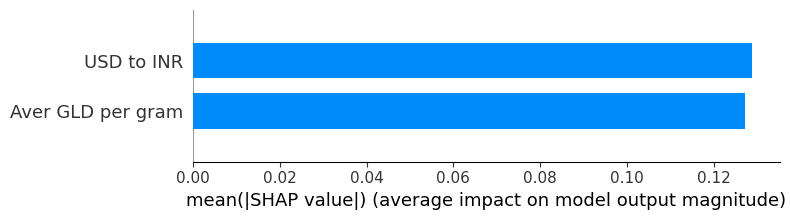

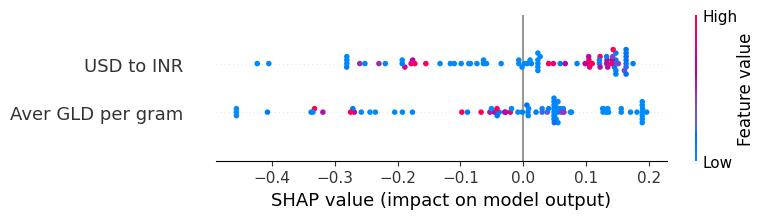

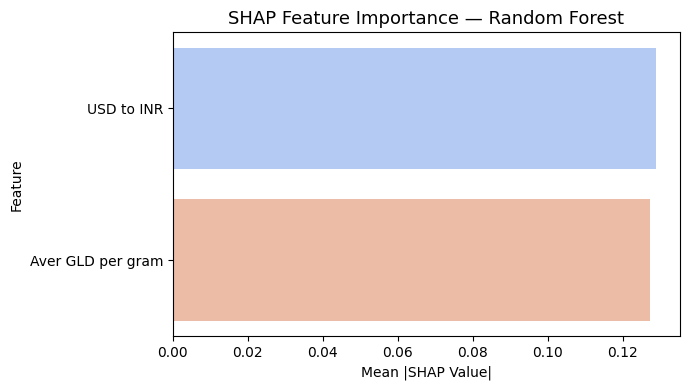

USD to INR                : 0.1288
Aver GLD per gram         : 0.1273


In [21]:
# ✅ UNIVERSAL — works for any SHAP version
explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_train)

sv = np.array(shap_values)

# Handle both 2D and 3D shapes automatically
if sv.ndim == 3:
    sv_class1 = sv[:,:,1] if sv.shape[2]==2 else sv[1]
elif sv.ndim == 2:
    sv_class1 = sv
else:
    sv_class1 = sv[1]

print('sv_class1 shape:', sv_class1.shape)
print('X_train shape  :', X_train.shape)

# --- Summary Bar Plot ---
shap.summary_plot(sv_class1, X_train, plot_type='bar')

# --- Beeswarm Plot ---
shap.summary_plot(sv_class1, X_train)

# --- Feature Importance Chart ---
shap_importance = np.abs(sv_class1).mean(axis=0)
feature_names   = X_train.columns

plt.figure(figsize=(7, 4))
sns.barplot(x=shap_importance, y=feature_names, palette='coolwarm')
plt.title('SHAP Feature Importance — Random Forest', fontsize=13)
plt.xlabel('Mean |SHAP Value|')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

for feat, imp in zip(feature_names, shap_importance):
    print(f'{feat:25s} : {imp:.4f}')

##  13. Save Model

In [22]:
joblib.dump(final_model, 'gold_model.pkl')
joblib.dump(scaler,      'gold_scaler.pkl')

print('✅ Model  saved → gold_model.pkl')
print('✅ Scaler saved → gold_scaler.pkl')
print('   Final Model : Random Forest Classifier')

✅ Model  saved → gold_model.pkl
✅ Scaler saved → gold_scaler.pkl
   Final Model : Random Forest Classifier


## 14. Gradio Deployment

In [ ]:
# ── 14. Gradio Deployment ─────────────────────────────────────────
import gradio as gr
import numpy as np
import datetime

def predict_gold_direction(gold_price_inr_10g, usd_to_inr, year_input):

    # Year — use input if given, else auto current year
    year = int(year_input) if year_input else datetime.datetime.now().year

    # USD/INR — use input if given, else auto from year map
    usd_inr_map = {
        2020: 74.10, 2021: 73.50, 2022: 78.65,
        2023: 82.50, 2024: 85.61, 2025: 87.16, 2026: 87.50
    }
    if not usd_to_inr:
        usd_to_inr = usd_inr_map.get(year, 87.50)

    # Derive other features internally
    gold_price_inr_gram = gold_price_inr_10g / 10
    avg_gold_usd        = gold_price_inr_gram / usd_to_inr

    # ML Model prediction
    raw_input      = np.array([[usd_to_inr, avg_gold_usd, gold_price_inr_10g]])
    scaled         = scaler.transform(raw_input)
    selected_input = scaled[:, selector.get_support()]
    prediction     = final_model.predict(selected_input)[0]

    if prediction == 1:
        return (
            f"📈  GOLD PRICE WILL GO UP NEXT YEAR\n"
            f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n"
            f"✅  ADVICE : BUY GOLD NOW\n"
            f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n\n"
            f"📊  Gold Price (10g) : ₹{gold_price_inr_10g:,.0f}\n"
            f"💱  USD/INR Rate     : ₹{usd_to_inr:.2f}\n"
            f"📅  Prediction       : {year} → {year+1}\n\n"
            f"💡  Gold prices are expected to RISE.\n"
            f"    This is a GOOD time to invest!\n"
            f"    Even ₹500/month SIP is a great start."
        )
    else:
        return (
            f"📉  GOLD PRICE MAY GO DOWN NEXT YEAR\n"
            f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n"
            f"⚠️   ADVICE : WAIT & WATCH\n"
            f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n\n"
            f"📊  Gold Price (10g) : ₹{gold_price_inr_10g:,.0f}\n"
            f"💱  USD/INR Rate     : ₹{usd_to_inr:.2f}\n"
            f"📅  Prediction       : {year} → {year+1}\n\n"
            f"💡  Prices may fall soon.\n"
            f"    Wait for a lower price before buying.\n"
            f"    Already have gold? HOLD it!"
        )

# ── Auto USD/INR for default display ─────────────────────────────
def get_default_usd_inr():
    usd_inr_map = {
        2020: 74.10, 2021: 73.50, 2022: 78.65,
        2023: 82.50, 2024: 85.61, 2025: 87.16, 2026: 87.50
    }
    return usd_inr_map.get(datetime.datetime.now().year, 87.50)

# ── Custom CSS ────────────────────────────────────────────────────
css = """
body, .gradio-container {
    background: linear-gradient(135deg, #0D0A1A, #1A0F35) !important;
    font-family: 'Segoe UI', sans-serif !important;
}
.gradio-container h1 {
    color: #D4AF37 !important;
    font-size: 26px !important;
    font-weight: 900 !important;
    text-align: center !important;
}
label span {
    color: #D4AF37 !important;
    font-weight: 700 !important;
    font-size: 13px !important;
}
input[type=number] {
    background: rgba(255,255,255,0.07) !important;
    border: 1.5px solid rgba(212,175,55,0.3) !important;
    border-radius: 10px !important;
    color: #F0EBF8 !important;
    font-size: 16px !important;
    padding: 12px !important;
}
textarea {
    background: #0F0A28 !important;
    border: 2px solid #D4AF37 !important;
    border-radius: 12px !important;
    color: #F5F0FF !important;
    font-size: 15px !important;
    padding: 14px !important;
}
"""

# ── Interface ─────────────────────────────────────────────────────
interface = gr.Interface(
    fn = predict_gold_direction,
    inputs = [
        gr.Number(
            label="🪙 Current Gold Price per 10g (INR)",
            value=96450,
            info="💡 Google 'gold price today india' — enter the 10 gram rate in ₹"
        ),
        gr.Number(
            label="💱 USD to INR Exchange Rate",
            value=get_default_usd_inr(),
            info="✅ Auto-filled — change only if you know today's exact rate"
        ),
        gr.Number(
            label="📅 Year (Optional)",
            value=None,
            info="⬜ Leave empty to use current year automatically"
        ),
    ],
    outputs = gr.Textbox(
        label="🤖 AI Prediction Result",
        lines=12,
    ),
    title       = "🥇 Gold Price Direction Predictor",
    description = "🇮🇳 Indian Investors · Enter today's gold rate — AI predicts UP or DOWN next year",
    css         = css,
    theme = gr.themes.Base(
        primary_hue   = "yellow",
        secondary_hue = "purple",
        neutral_hue   = "slate",
        font          = gr.themes.GoogleFont("DM Sans"),
    ).set(
        body_background_fill     = "#0D0A1A",
        body_text_color          = "#F0EBF8",
        block_background_fill    = "#1A1235",
        block_border_color       = "rgba(212,175,55,0.2)",
        block_label_text_color   = "#D4AF37",
        input_background_fill    = "rgba(255,255,255,0.06)",
        input_border_color       = "rgba(212,175,55,0.25)",
        input_border_color_focus = "#D4AF37",
        button_primary_background_fill   = "linear-gradient(135deg,#D4AF37,#C0890A)",
        button_primary_text_color        = "#0D0A1A",
    ),
    examples = [
        [96450, 87.50, None],
        [85000, 85.61, 2024],
        [78240, 83.50, 2023],
        [63200, 82.50, None],
    ],
    flagging_mode = "never",
)

interface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7864

Could not create share link. Missing file: C:\Users\Asus\.cache\huggingface\gradio\frpc\frpc_windows_amd64_v0.3. 

Please check your internet connection. This can happen if your antivirus software blocks the download of this file. You can install manually by following these steps: 

1. Download this file: https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_windows_amd64.exe
2. Rename the downloaded file to: frpc_windows_amd64_v0.3
3. Move the file to this location: C:\Users\Asus\.cache\huggingface\gradio\frpc


Traceback (most recent call last):
  File "c:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\gradio\queueing.py", line 766, in process_events
    response = await route_utils.call_process_api(
  File "c:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\gradio\route_utils.py", line 355, in call_process_api
    output = await app.get_blocks().process_api(
  File "c:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\gradio\blocks.py", line 2152, in process_api
    result = await self.call_function(
  File "c:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\gradio\blocks.py", line 1629, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
  File "c:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\anyio\to_thread.py", line 63, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
  File "c:\Users\Asus\AppData\Local\Programs\Python\Python31